Crime Data in 2020-2024

Being in touch with how your community is doing is an essential part to thriving in it. Although crime and police activity is often be talked about its so rarely quantified. So the question came forward "are our neighborhoods getting safer or less safe?" with the passing of COVID many people began to summize that the world is getting just a more crazy. To see if that is true I will be looking at crime from 2020-2024 for LA county to see if theres been an increase in crime in its entiery or by type of crime.

In [ ]:
#import libraries
import urllib.request
import json
import pymongo
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, linregress


First step of any good analysis is pulling up our data to analysis, we will be pulling our data from data.gov.

In [3]:
#call url and read data
Crime="https://data.lacity.org/api/views/2nrs-mtv8/rows.json?accessType=DOWNLOAD"
open=urllib.request.urlopen(Crime)
read=open.read().decode('utf-8')

In [4]:
#convert the Json to python readable
converted=json.loads(read)
Title=converted['meta']['view']['name']
print(Title)

Crime Data from 2020 to 2024


Let's make sure we have all the keys so we know what we are looking for and at.

In [5]:
#find all keys in the json file
def get_all_keys(json_object, keys_list):
    if isinstance(json_object, dict):
        keys_list.extend(json_object.keys())
        for value in json_object.values():
            get_all_keys(value, keys_list)
    elif isinstance(json_object, list):
        for item in json_object:
            get_all_keys(item, keys_list)
    return keys_list

keys=[]
keys=get_all_keys(converted,keys)
print(keys)

['meta', 'data', 'view', 'id', 'name', 'assetType', 'attribution', 'attributionLink', 'averageRating', 'category', 'createdAt', 'description', 'diciBackend', 'displayType', 'downloadCount', 'hideFromCatalog', 'hideFromDataJson', 'licenseId', 'locked', 'newBackend', 'numberOfComments', 'oid', 'provenance', 'publicationAppendEnabled', 'publicationDate', 'publicationGroup', 'publicationStage', 'rowsUpdatedAt', 'rowsUpdatedBy', 'tableId', 'totalTimesRated', 'viewCount', 'viewLastModified', 'viewType', 'approvals', 'clientContext', 'columns', 'grants', 'license', 'metadata', 'owner', 'query', 'rights', 'tableAuthor', 'tags', 'flags', 'reviewedAt', 'reviewedAutomatically', 'state', 'submissionId', 'submissionObject', 'submissionOutcome', 'submittedAt', 'targetAudience', 'workflowId', 'reviewer', 'submissionDetails', 'submissionOutcomeApplication', 'submitter', 'id', 'displayName', 'permissionType', 'endedAt', 'failureCount', 'startedAt', 'status', 'id', 'displayName', 'clientContextVariables

Now lets explore the meta data before we go to our acutal data.

In [6]:
meta=converted['meta']
meta['view'].keys()


dict_keys(['id', 'name', 'assetType', 'attribution', 'attributionLink', 'averageRating', 'category', 'createdAt', 'description', 'diciBackend', 'displayType', 'downloadCount', 'hideFromCatalog', 'hideFromDataJson', 'licenseId', 'locked', 'newBackend', 'numberOfComments', 'oid', 'provenance', 'publicationAppendEnabled', 'publicationDate', 'publicationGroup', 'publicationStage', 'rowsUpdatedAt', 'rowsUpdatedBy', 'tableId', 'totalTimesRated', 'viewCount', 'viewLastModified', 'viewType', 'approvals', 'clientContext', 'columns', 'grants', 'license', 'metadata', 'owner', 'query', 'rights', 'tableAuthor', 'tags', 'flags'])

Now that we've looked at the meta data we can see that our column names are in the meta keys so we will need that information when creating a dataframe.

In [25]:
data = converted['data']

# inspect
print(type(data), len(data))
print(data[0])

# make a DataFrame
cols = [c['name'] for c in converted['meta']['view']['columns']]
df = pd.DataFrame(data, columns=cols)
df.head()


<class 'list'> 1004894
['row-q7ta_r36w~7ugk', '00000000-0000-0000-FE7C-9226283E2B24', 0, 1731507643, None, 1731507643, None, '{ }', '211507896', '2021-04-11T00:00:00', '2020-11-07T00:00:00', '0845', '15', 'N Hollywood', '1502', '2', '354', 'THEFT OF IDENTITY', '0377', '31', 'M', 'H', '501', 'SINGLE FAMILY DWELLING', None, None, 'IC', 'Invest Cont', '354', None, None, None, '7800    BEEMAN                       AV', None, '34.2124', '-118.4092']


,sid,id,position,created_at,created_meta,updated_at,updated_meta,meta,DR_NO,Date Rptd,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,row-q7ta_r36w~7ugk,00000000-0000-0000-FE7C-9226283E2B24,0,1731507643,None,1731507643,None,{ },211507896,2021-04-11T00:00:00,...,IC,Invest Cont,354,None,None,None,7800 BEEMAN AV,None,34.2124,-118.4092
1,row-u62f-5wff_cxhk,00000000-0000-0000-F3B3-23FB73570CB9,0,1731507643,None,1731507643,None,{ },201516622,2020-10-21T00:00:00,...,IC,Invest Cont,230,None,None,None,ATOLL AV,N GAULT,34.1993,-118.4203
2,row-rd9m_rzn6_humf,00000000-0000-0000-ACC5-5AB73B28EA5A,0,1735135924,None,1735135924,None,{ },240913563,2024-12-10T00:00:00,...,IC,Invest Cont,354,None,None,None,14600 SYLVAN ST,None,34.1847,-118.4509
3,row-9kpm.zfd4_z2ac,00000000-0000-0000-D013-20960405E03D,0,1731507643,None,1731507643,None,{ },210704711,2020-12-24T00:00:00,...,IC,Invest Cont,331,None,None,None,6000 COMEY AV,None,34.0339,-118.3747
4,row-3wnd-s8da-ngzr,00000000-0000-0000-0069-77A1650A93DE,0,1731507643,None,1731507643,None,{ },201418201,2020-10-03T00:00:00,...,IC,Invest Cont,420,None,None,None,4700 LA VILLA MARINA,None,33.9813,-118.435


It appears our data has 36 columns which is quite a lot but all we are really concenerd about for our question is the rate at which crime is occuring and if its truly changing.

Now lets load it into into our MongoDb so we can pull it out later

In [8]:
try:
    client = pymongo.MongoClient('localhost', 27017)
    print("Connected successfully!!!")
except pymongo.errors.ConnectionFailure as e:
    print("Could not connect to MongoDB: %s" % e)
else:
    # create database market
    db = client.crimestats
    # create markets collection
    crime = db.crimestats
    # convert records to list of dictionaries using columns as keys
    data_to_insert = [dict(zip(cols, record)) for record in data]
    # insert the data
    crime.insert_many(data_to_insert)
    print("Added", len(data_to_insert), "crime stats added added to database")
    # close the database connection
    client.close()


Connected successfully!!!
Added 1004894 crime stats added added to database


The data is now ready for cleanup and analysis.

In [9]:
null_per_column= df.isnull().sum()
print('Nulls count per columns:',null_per_column)

Nulls count per columns: sid                     0
id                      0
position                0
created_at              0
created_meta      1004894
updated_at              0
updated_meta      1004894
meta                    0
DR_NO                   0
Date Rptd               0
DATE OCC                0
TIME OCC                0
AREA                    0
AREA NAME               0
Rpt Dist No             0
Part 1-2                0
Crm Cd                  0
Crm Cd Desc             0
Mocodes            151598
Vict Age                0
Vict Sex           144631
Vict Descent       144643
Premis Cd              16
Premis Desc           588
Weapon Used Cd     677678
Weapon Desc        677678
Status                  1
Status Desc             0
Crm Cd 1               11
Crm Cd 2           935740
Crm Cd 3          1002580
Crm Cd 4          1004830
LOCATION                0
Cross Street       850666
LAT                     0
LON                     0
dtype: int64


It appears there is quite a few N/A's but because the N/A's don't have a big effect on the question we are trying to answer I will not do anything with those N/A's.

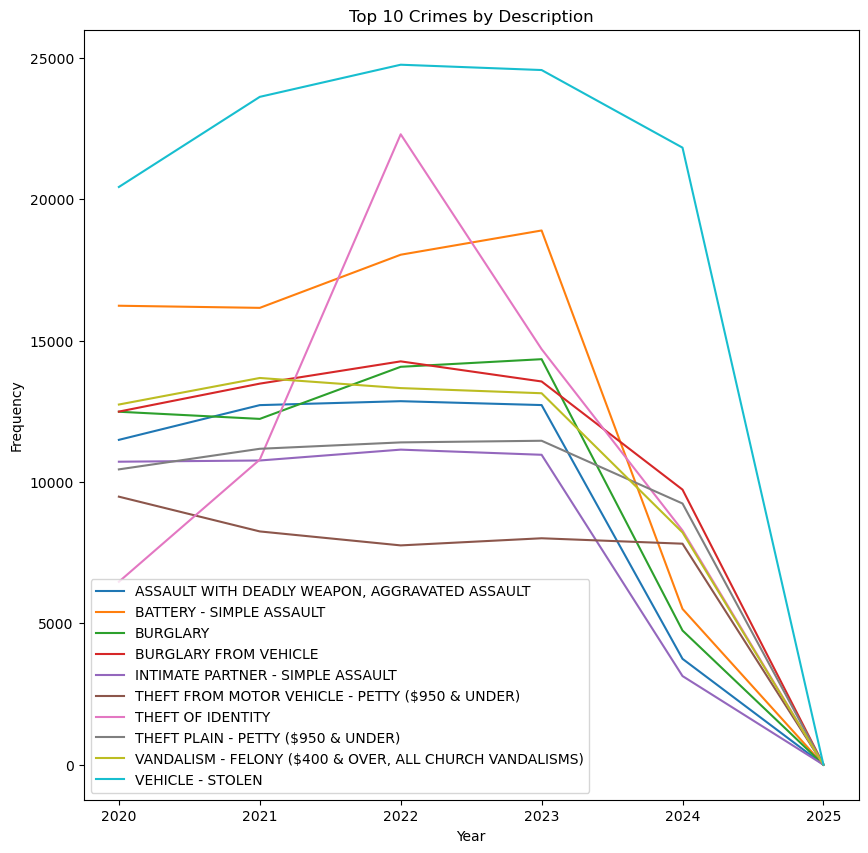

In [23]:
def numerical_analysis (data):
    #take a large sample of the data for analysis
    sample=data
    sample['Date Rptd']=pd.to_datetime( sample['Date Rptd'])

    #create a dataset of time and the crime codes
    crime_numbers = sample.loc[:,['Date Rptd','Crm Cd Desc']]
    
    # Extract year from date for analysis
    crime_numbers['Year'] = crime_numbers['Date Rptd'].dt.year
    
    # Get top 10 crime descriptions by total count
    top_crimes = crime_numbers['Crm Cd Desc'].value_counts().head(10).index
    
    # Filter to only top 10 crimes
    crime_numbers_filtered = crime_numbers[crime_numbers['Crm Cd Desc'].isin(top_crimes)]
    
    # Group by year and crime description, count occurrences, and plot as line chart
    crime_counts = crime_numbers_filtered.groupby(['Year', 'Crm Cd Desc']).size().unstack()
    crime_counts.plot(kind='line', figsize=(10, 10))
    plt.xlabel('Year')
    plt.ylabel('Frequency')
    plt.title('Top 10 Crimes by Description')
    plt.legend(loc='best')
numerical_analysis(df)

looking at just the top 10 occuring crimes it does appear that there has been a decrease in crime but we don't know yet if it significant.

In [ ]:
# ensure year column
df['Date Rptd'] = pd.to_datetime(df['Date Rptd'])
df['Year'] = df['Date Rptd'].dt.year

# choose top N crimes overall
top_n = 10
top_crimes = df['Crm Cd Desc'].value_counts().head(top_n).index

# contingency table year x crime
ct = pd.crosstab(df.loc[df['Crm Cd Desc'].isin(top_crimes), 'Year'],
                 df.loc[df['Crm Cd Desc'].isin(top_crimes), 'Crm Cd Desc'])

#chi 2 test for population expected vs actual.
chi2, p, dof, ex = chi2_contingency(ct)
print(f"Chi-square test for Year vs Crm Cd Desc (top {top_n}): chi2={chi2:.2f}, p={p:.4f}, dof={dof}")

if p < 0.05:
    print("Significant change in distribution of top crimes across years (p < 0.05).")
else:
    print("No significant change in distribution of top crimes across years (p >= 0.05).")

# trend per crime
print("\nYearly trend p-values for top crimes:")
for crime in top_crimes:
    yearly = df[df['Crm Cd Desc'] == crime].groupby('Year').size().reindex(sorted(df['Year'].unique()), fill_value=0)
    slope, intercept, r_value, p_val, std_err = linregress(yearly.index.astype(float), yearly.values)
    sign = "increasing" if slope > 0 else "decreasing" if slope < 0 else "flat"
    print(f"{crime}: slope={slope:.2f}, p={p_val:.4f}, trend={sign}")



Chi-square test for Year vs Crm Cd Desc (top 10): chi2=21182.94, p=0.0000, dof=45
Significant change in distribution of top crimes across years (p < 0.05).

Yearly trend p-values for top crimes:
VEHICLE - STOLEN: slope=-3077.31, p=0.2053, trend=decreasing
BATTERY - SIMPLE ASSAULT: slope=-3206.37, p=0.0736, trend=decreasing
BURGLARY FROM VEHICLE: slope=-2124.14, p=0.0973, trend=decreasing
THEFT OF IDENTITY: slope=-1355.60, p=0.5174, trend=decreasing
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS): slope=-2292.23, p=0.0576, trend=decreasing
BURGLARY: slope=-2416.43, p=0.0746, trend=decreasing
THEFT PLAIN - PETTY ($950 & UNDER): slope=-1654.91, p=0.1260, trend=decreasing
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT: slope=-2413.86, p=0.0532, trend=decreasing
INTIMATE PARTNER - SIMPLE ASSAULT: slope=-2189.09, p=0.0397, trend=decreasing
THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER): slope=-1383.86, p=0.0829, trend=decreasing


Although all top 10 crimes show a decrease, only simple assault on an intimate partner has a significant p-value. This suggests that the overall decline may not be due to reductions in each individual crime. The ongoing updates and data imputation especially given the sensitivity of the data could mean some crimes have yet to be reported within this data set.